In [13]:
# Cell 1 - Imports & Config
import os, sys, math, random, shutil, json
from glob import glob
from collections import defaultdict
from tqdm.auto import tqdm

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import nibabel as nib
import pydicom

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torch.optim as optim
import torch.nn.functional as F

# ---------- Config (tune these) ----------
ROOT = "/kaggle/input/rsna-intracranial-aneurysm-detection"
FILTERED_CSV = "/kaggle/input/rsna-filtered-set/train_masked.csv"   # your filtered set (with nii_mask column)
LOCALIZERS_CSV = os.path.join(ROOT, "train_localizers.csv")       # competition localizers file
SEG_FOLDER = os.path.join(ROOT, "segmentations")
SERIES_FOLDER = os.path.join(ROOT, "series")

OUTPUT_DIR = "/kaggle/working/patient_visuals"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Training defaults (safe for 16GB GPU / ~29GB RAM; reduce to run quicker)
SEED = 42
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

N_PATIENTS = 10        # number of patients to use (start small)
PATCH_SIZE = (64, 128, 128)  # (D, H, W) patch size in voxels - depth small (64)
BATCH_SIZE = 2
NUM_EPOCHS = 3
LR = 1e-4
NUM_WORKERS = 0  # 0 on Kaggle to reduce RAM pressure

# Multi-class label names from competition (order -> class id)
LABEL_COLS = [
    'Left Infraclinoid Internal Carotid Artery',
    'Right Infraclinoid Internal Carotid Artery',
    'Left Supraclinoid Internal Carotid Artery',
    'Right Supraclinoid Internal Carotid Artery',
    'Left Middle Cerebral Artery',
    'Right Middle Cerebral Artery',
    'Anterior Communicating Artery',
    'Left Anterior Cerebral Artery',
    'Right Anterior Cerebral Artery',
    'Left Posterior Communicating Artery',
    'Right Posterior Communicating Artery',
    'Basilar Tip',
    'Other Posterior Circulation',
]
NUM_CLASSES = len(LABEL_COLS) + 1  # +1 for background (class 0)

# reproducibility
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("Device:", device, "PATCH_SIZE:", PATCH_SIZE, "BATCH_SIZE:", BATCH_SIZE)


Device: cuda PATCH_SIZE: (64, 128, 128) BATCH_SIZE: 2


In [14]:
# Cell 2 - Utilities
from skimage.transform import resize as sk_resize
from scipy.ndimage import gaussian_filter, binary_fill_holes

def load_dicom_series(series_folder):
    """Load a DICOM series into a (D,H,W) numpy array (int16). Sort by ImagePositionPatient z or InstanceNumber."""
    files = [os.path.join(series_folder, f) for f in os.listdir(series_folder) if f.lower().endswith(".dcm")]
    if len(files) == 0:
        raise FileNotFoundError("No DICOMs in " + series_folder)
    # read meta only to sort
    slices = []
    for fp in files:
        try:
            ds = pydicom.dcmread(fp, stop_before_pixels=True, force=True)
            z = None
            if hasattr(ds, "ImagePositionPatient"):
                z = float(ds.ImagePositionPatient[2])
            elif hasattr(ds, "InstanceNumber"):
                z = float(ds.InstanceNumber)
            slices.append((z, fp))
        except Exception as e:
            # skip bad files
            continue
    slices.sort(key=lambda x: x[0])
    imgs = []
    for _, fp in slices:
        ds = pydicom.dcmread(fp, force=True)
        arr = ds.pixel_array.astype(np.float32)
        imgs.append(arr)
    vol = np.stack(imgs)  # (D, H, W)
    return vol

def load_nifti_volume(nii_path):
    """Load nifti to numpy (D,H,W) float32"""
    img = nib.load(nii_path)
    data = img.get_fdata().astype(np.float32)
    # nib often returns (X,Y,Z) where axis order may differ; assume data in (Z,Y,X) or (D,H,W).
    # We want shape (D,H,W). If shape[2] is smallest assume it's D last; try to detect:
    if data.shape[0] < data.shape[2] and data.shape[0] < data.shape[1]:
        # likely (D,H,W) already
        return data
    # else try to transpose
    return np.transpose(data, (2,1,0))

# map SeriesInstanceUID -> mask path if available
def find_mask_path(series_uid):
    # prefer _cowseg if present
    p1 = os.path.join(SEG_FOLDER, f"{series_uid}_cowseg.nii")
    p2 = os.path.join(SEG_FOLDER, f"{series_uid}.nii")
    if os.path.exists(p1): return p1
    if os.path.exists(p2): return p2
    return None

# load localizers CSV into a dict for quick lookup
if os.path.exists(LOCALIZERS_CSV):
    localizer_df = pd.read_csv(LOCALIZERS_CSV)
else:
    localizer_df = pd.DataFrame(columns=["SeriesInstanceUID","SOPInstanceUID","coordinates","location"])

# helper: synthesize multiclass mask from localizers.csv
def synthesize_mask_from_localizer(series_uid, vol_shape, radius=6):
    """
    vol_shape: (D,H,W)
    We'll read localizer entries for this series and place a small disk/ball at the given x,y and InstanceNumber slice.
    The coordinates in CSV are 2D (x,y) — we need corresponding slice index: find SOPInstanceUID -> which dcm -> its index.
    Returns integer mask of shape vol_shape with class ids (0 background, 1..N classes).
    """
    mask = np.zeros(vol_shape, dtype=np.uint8)
    rows = localizer_df[localizer_df["SeriesInstanceUID"] == series_uid]
    if rows.empty:
        return mask
    # build map SOPInstanceUID -> slice index by reading series folder filenames (they are SOPInstanceUID.dcm)
    series_folder = os.path.join(SERIES_FOLDER, series_uid)
    if not os.path.exists(series_folder):
        return mask
    files = sorted([f for f in os.listdir(series_folder) if f.lower().endswith(".dcm")])
    # map file basename without .dcm to index
    sop_to_idx = {}
    # read InstanceNumber order to be safe
    slices_meta = []
    for f in files:
        path = os.path.join(series_folder, f)
        try:
            ds = pydicom.dcmread(path, stop_before_pixels=True, force=True)
            inst = getattr(ds, "InstanceNumber", None)
            sop = getattr(ds, "SOPInstanceUID", None)
            z = float(ds.ImagePositionPatient[2]) if hasattr(ds, "ImagePositionPatient") else (inst or 0)
            slices_meta.append((z, sop, f))
        except Exception:
            continue
    slices_meta.sort(key=lambda x: x[0])
    for idx, (_, sop, fname) in enumerate(slices_meta):
        if sop:
            sop_to_idx[sop] = idx

    # parse each localizer row and mark a small disk
    for _, r in rows.iterrows():
        try:
            sop = r["SOPInstanceUID"]
            coord = r["coordinates"]
            # coordinates stored as string dict; parse
            if isinstance(coord, str):
                coord_d = eval(coord)
            else:
                coord_d = coord
            x = int(coord_d["x"]); y = int(coord_d["y"])
            # map location name to class id
            loc = r.get("location", "")
            if loc in LABEL_COLS:
                cls = LABEL_COLS.index(loc) + 1
            else:
                cls = len(LABEL_COLS)  # "other" -> last class
            zidx = sop_to_idx.get(sop, vol_shape[0]//2)
            # draw a small disk in mask[zidx]
            ys, xs = np.ogrid[:vol_shape[1], :vol_shape[2]]
            mask_slice = ((ys - y)**2 + (xs - x)**2) <= (radius**2)
            mask[zidx][mask_slice] = cls
        except Exception:
            continue
    # do small gaussian & fill to make it less sparse
    for c in range(1, NUM_CLASSES):
        binary = (mask == c).astype(np.uint8)
        if binary.sum() == 0: continue
        # optional grow
        binary = binary.astype(np.float32)
        binary = gaussian_filter(binary, sigma=1)
        mask[binary > 0.01] = c
    return mask


In [16]:
class VolumePatchDataset(Dataset):
    def __init__(self, df, n_patients=None, patch_size=PATCH_SIZE, positive_ratio=0.8, cache_size=4):
        self.df = df.copy().reset_index(drop=True)
        if n_patients:
            self.df = self.df.head(n_patients)
        self.series_uids = self.df["SeriesInstanceUID"].tolist()
        self.patch_size = patch_size
        self.positive_ratio = positive_ratio
        self.cache = {}
        self.cache_order = []
        self.cache_size = cache_size

    def __len__(self):
        return len(self.series_uids) * 20

    def _load_pair(self, series_uid):
        mask_path = find_mask_path(series_uid)
        if mask_path:
            mask = load_nifti_volume(mask_path).astype(np.uint8)
        else:
            mask = None
        possible_nii = os.path.join(SEG_FOLDER, f"{series_uid}.nii")
        if os.path.exists(possible_nii):
            img = load_nifti_volume(possible_nii).astype(np.float32)
        else:
            img = load_dicom_series(os.path.join(SERIES_FOLDER, series_uid)).astype(np.float32)
        if mask is None:
            mask = synthesize_mask_from_localizer(series_uid, img.shape, radius=6)
        else:
            if mask.shape != img.shape:
                mask_resized = sk_resize(mask, img.shape, order=0, preserve_range=True, anti_aliasing=False)
                mask = (mask_resized > 0.5).astype(np.uint8)
        mn, mx = img.min(), img.max()
        img = (img - mn) / (mx - mn + 1e-9)
        return img.astype(np.float32), mask.astype(np.uint8)

    def _get_cached(self, series_uid):
        if series_uid in self.cache:
            return self.cache[series_uid]
        img, mask = self._load_pair(series_uid)
        self.cache[series_uid] = (img, mask)
        self.cache_order.append(series_uid)
        if len(self.cache_order) > self.cache_size:
            old = self.cache_order.pop(0)
            del self.cache[old]
        return img, mask

    def __getitem__(self, idx):
        sid = random.choice(self.series_uids)
        img, mask = self._get_cached(sid)
        D,H,W = img.shape
        pd, ph, pw = self.patch_size

        # Force positive patch if possible and probabilistically
        slice_sums = mask.sum(axis=(1,2))
        pos_slices = np.where(slice_sums > 0)[0]
        if len(pos_slices) > 0 and random.random() < self.positive_ratio:
            z = int(random.choice(pos_slices))
        else:
            z = random.randint(0, max(0, D-1))

        z0 = np.clip(z - pd//2, 0, max(0, D - pd))
        z0 = int(z0 + random.randint(0, max(0, min(pd//4, D-1))))  # jitter
        top = random.randint(0, max(0, H - ph)) if H > ph else 0
        left = random.randint(0, max(0, W - pw)) if W > pw else 0

        vol_patch = img[z0:z0+pd, top:top+ph, left:left+pw]
        mask_patch = mask[z0:z0+pd, top:top+ph, left:left+pw]

        # pad if needed
        if vol_patch.shape != (pd, ph, pw):
            p = np.zeros((pd, ph, pw), dtype=vol_patch.dtype)
            p[:vol_patch.shape[0], :vol_patch.shape[1], :vol_patch.shape[2]] = vol_patch
            vol_patch = p
        if mask_patch.shape != (pd, ph, pw):
            p = np.zeros((pd, ph, pw), dtype=mask_patch.dtype)
            p[:mask_patch.shape[0], :mask_patch.shape[1], :mask_patch.shape[2]] = mask_patch
            mask_patch = p

        if random.random() < 0.5:
            vol_patch = np.flip(vol_patch, axis=2).copy()
            mask_patch = np.flip(mask_patch, axis=2).copy()
        if random.random() < 0.5:
            vol_patch = np.flip(vol_patch, axis=1).copy()
            mask_patch = np.flip(mask_patch, axis=1).copy()

        x = torch.from_numpy(vol_patch).unsqueeze(0).float()
        y = torch.from_numpy(mask_patch).long()
        return x, y


In [17]:
# Cell 4 - 3D UNet (small)
class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv3d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm3d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv3d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm3d(out_ch),
            nn.ReLU(inplace=True)
        )
    def forward(self,x): return self.net(x)

class UNet3D(nn.Module):
    def __init__(self, in_ch=1, num_classes=NUM_CLASSES, base_ch=16):
        super().__init__()
        self.enc1 = ConvBlock(in_ch, base_ch)
        self.pool1 = nn.MaxPool3d(2)
        self.enc2 = ConvBlock(base_ch, base_ch*2)
        self.pool2 = nn.MaxPool3d(2)
        self.enc3 = ConvBlock(base_ch*2, base_ch*4)
        self.pool3 = nn.MaxPool3d(2)
        self.bottleneck = ConvBlock(base_ch*4, base_ch*8)

        self.up3 = nn.ConvTranspose3d(base_ch*8, base_ch*4, kernel_size=2, stride=2)
        self.dec3 = ConvBlock(base_ch*8, base_ch*4)
        self.up2 = nn.ConvTranspose3d(base_ch*4, base_ch*2, kernel_size=2, stride=2)
        self.dec2 = ConvBlock(base_ch*4, base_ch*2)
        self.up1 = nn.ConvTranspose3d(base_ch*2, base_ch, kernel_size=2, stride=2)
        self.dec1 = ConvBlock(base_ch*2, base_ch)

        self.outconv = nn.Conv3d(base_ch, num_classes, kernel_size=1)

    def forward(self, x):
        e1 = self.enc1(x)
        p1 = self.pool1(e1)
        e2 = self.enc2(p1)
        p2 = self.pool2(e2)
        e3 = self.enc3(p2)
        p3 = self.pool3(e3)
        b = self.bottleneck(p3)
        u3 = self.up3(b)
        d3 = self.dec3(torch.cat([u3, e3], dim=1))
        u2 = self.up2(d3)
        d2 = self.dec2(torch.cat([u2, e2], dim=1))
        u1 = self.up1(d2)
        d1 = self.dec1(torch.cat([u1, e1], dim=1))
        out = self.outconv(d1)
        return out

# instantiate
model = UNet3D(in_ch=1, num_classes=NUM_CLASSES, base_ch=16).to(device)
print("Model params:", sum(p.numel() for p in model.parameters())/1e6, "M")


Model params: 1.401486 M


In [19]:
# Cell 5 - Losses & metrics
def one_hot(labels, num_classes):
    # labels: (N, D, H, W) long
    shape = (labels.shape[0], num_classes, labels.shape[1], labels.shape[2], labels.shape[3])
    out = torch.zeros(shape, device=labels.device, dtype=torch.float32)
    return out.scatter_(1, labels.unsqueeze(1), 1.0)

def dice_per_class(pred_probs, targets_onehot, eps=1e-6):
    # pred_probs: (N, C, D,H,W)
    dims = (2,3,4)
    inter = (pred_probs * targets_onehot).sum(dim=dims)
    union = pred_probs.sum(dim=dims) + targets_onehot.sum(dim=dims)
    dice = (2*inter + eps) / (union + eps)
    return dice  # (N, C)

class DiceCELoss(nn.Module):
    def __init__(self, ce_weight=1.0, dice_weight=1.0):
        super().__init__()
        self.ce = nn.CrossEntropyLoss()
        self.ce_w = ce_weight
        self.dice_w = dice_weight

    def forward(self, logits, targets):
        # logits: (N,C,D,H,W) targets: (N,D,H,W) long
        ce_loss = self.ce(logits, targets)
        probs = F.softmax(logits, dim=1)
        targets_oh = one_hot(targets, logits.shape[1])
        dice = dice_per_class(probs, targets_oh).mean()
        # we want to minimize, so dice -> 1 - dice
        dice_loss = 1.0 - dice
        return self.ce_w * ce_loss + self.dice_w * dice_loss

# ---- Dice Loss New ---- #
# class DiceLoss(nn.Module):
#     def __init__(self, smooth=1e-6):
#         """
#         smooth: to avoid division by zero
#         """
#         super(DiceLoss, self).__init__()
#         self.smooth = smooth

#     def forward(self, pred, target):
#         """
#         pred: output logits or probabilities from model (B,1,H,W) or (B,C,H,W)
#         target: ground truth mask (B,1,H,W) or (B,C,H,W)
#         """
#         # apply sigmoid if logits
#         if pred.max() > 1.0:
#             pred = torch.sigmoid(pred)

#         pred_flat = pred.contiguous().view(pred.shape[0], -1)
#         target_flat = target.contiguous().view(target.shape[0], -1)

#         intersection = (pred_flat * target_flat).sum(dim=1)
#         union = pred_flat.sum(dim=1) + target_flat.sum(dim=1)

#         dice = (2. * intersection + self.smooth) / (union + self.smooth)
#         return 1 - dice.mean()  # Dice loss
        

# # ---- Combined BCE + Dice Loss ---- #
# class BCEDiceLoss(nn.Module):
#     def __init__(self, bce_weight=0.5):
#         super(BCEDiceLoss, self).__init__()
#         self.bce_weight = bce_weight
#         self.bce = nn.BCEWithLogitsLoss()
#         self.dice = DiceLoss()

#     def forward(self, pred, target):
#         bce_loss = self.bce(pred, target)
#         dice_loss = self.dice(pred, target)
#         return self.bce_weight * bce_loss + (1 - self.bce_weight) * dice_loss


def compute_metrics(logits, targets):
    # returns average dice (excluding background) and pixel accuracy
    with torch.no_grad():
        probs = F.softmax(logits, dim=1)
        preds = probs.argmax(dim=1)  # (N,D,H,W)
        acc = (preds == targets).float().mean().item()
        # per-class dice (average over batch)
        targets_oh = one_hot(targets, logits.shape[1])
        d = dice_per_class(probs, targets_oh)  # (N,C)
        d_mean = d.mean(dim=0).cpu().numpy()  # per-class
        # exclude background (class 0) for reporting
        if logits.shape[1] > 1:
            mean_foreground_dice = float(np.mean(d_mean[1:]))
        else:
            mean_foreground_dice = float(d_mean[0])
        return mean_foreground_dice, acc


criterion = DiceCELoss(ce_weight=1.0, dice_weight=1.0)
# criterion = BCEDiceLoss(bce_weight=0.5).to(device) #new

class WeightedDiceCELoss(nn.Module):
    def __init__(self, class_weights=None, ce_weight=1.0, dice_weight=1.0):
        super().__init__()
        self.ce = nn.CrossEntropyLoss(weight=class_weights)
        self.ce_w = ce_weight
        self.dice_w = dice_weight

    def forward(self, logits, targets):
        ce_loss = self.ce(logits, targets)
        probs = F.softmax(logits, dim=1)
        targets_oh = one_hot(targets, logits.shape[1])
        dice = dice_per_class(probs, targets_oh).mean()
        dice_loss = 1.0 - dice
        return self.ce_w * ce_loss + self.dice_w * dice_loss

# Example: set higher weights for aneurysm classes (1..NUM_CLASSES-1), background weight=1.0
weights = torch.ones(NUM_CLASSES)
weights[1:] = 5.0  # weight aneurysm classes more strongly, adjust factor as needed
weights = weights.to(device)
criterion = WeightedDiceCELoss(class_weights=weights, ce_weight=1.0, dice_weight=1.0)


In [20]:
df = pd.read_csv(FILTERED_CSV)
df = df[df['SeriesInstanceUID'].notna()].reset_index(drop=True)
N_PATIENTS = min(50, len(df))  # increase patients if memory allows
train_df = df.head(N_PATIENTS)
n_train = int(0.85 * N_PATIENTS)
train_df_sub = train_df.head(n_train)
val_df_sub = train_df.tail(N_PATIENTS - n_train)

train_ds = VolumePatchDataset(train_df_sub, patch_size=PATCH_SIZE, positive_ratio=0.8, cache_size=4)
val_ds = VolumePatchDataset(val_df_sub, patch_size=PATCH_SIZE, positive_ratio=0.0, cache_size=4)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=False)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=False)

print("Train patients:", len(train_ds.series_uids), "Val patients:", len(val_ds.series_uids))
print("Train batches per epoch:", len(train_loader))


Train patients: 42 Val patients: 8
Train batches per epoch: 420


In [22]:
# Cell 7 - Safe train step & training loop
def safe_train_step(model, data, target, optimizer, loss_fn):
    global BATCH_SIZE
    while True:
        try:
            data, target = data.to(device), target.to(device)
            optimizer.zero_grad()
            logits = model(data)
            loss = loss_fn(logits, target)
            loss.backward()
            optimizer.step()
            return loss.item()
        except RuntimeError as e:
            if "out of memory" in str(e):
                torch.cuda.empty_cache()
                if BATCH_SIZE > 1:
                    BATCH_SIZE //= 2
                    print(f"OOM -> reducing BATCH_SIZE to {BATCH_SIZE}")
                    return None
                else:
                    raise
            else:
                raise

optimizer = optim.Adam(model.parameters(), lr=LR)
train_loss_hist, val_loss_hist, val_dice_hist, val_acc_hist = [], [], [], []
best_dice = -1.0

for epoch in range(1, NUM_EPOCHS+1):
    model.train()
    running_loss = 0.0
    pbar = tqdm(train_loader, desc=f"Epoch {epoch}/{NUM_EPOCHS} train", leave=False)
    for xb, yb in pbar:
        loss_val = safe_train_step(model, xb, yb, optimizer, criterion)
        if loss_val is not None:
            running_loss += loss_val
            pbar.set_postfix({"loss": running_loss / (pbar.n + 1e-9)})

    avg_train_loss = running_loss / max(1, len(train_loader))
    train_loss_hist.append(avg_train_loss)

    # validation
    model.eval()
    val_loss = 0.0
    dices, accs = [], []
    with torch.no_grad():
        for xb, yb in tqdm(val_loader, desc=f"Epoch {epoch}/{NUM_EPOCHS} val", leave=False):
            xb = xb.to(device)
            yb = yb.to(device)
            logits = model(xb)
            loss = criterion(logits, yb)
            val_loss += loss.item()
            mean_dice, acc = compute_metrics(logits, yb)
            dices.append(mean_dice)
            accs.append(acc)

    avg_val_loss = val_loss / max(1, len(val_loader))
    avg_val_dice = float(np.mean(dices)) if len(dices) else 0.0
    avg_val_acc = float(np.mean(accs)) if len(accs) else 0.0
    val_loss_hist.append(avg_val_loss)
    val_dice_hist.append(avg_val_dice)
    val_acc_hist.append(avg_val_acc)

    print(f"Epoch {epoch}: TrainLoss {avg_train_loss:.4f} | ValLoss {avg_val_loss:.4f} | ValDice {avg_val_dice:.4f} | ValAcc {avg_val_acc:.4f}")

    if avg_val_dice > best_dice:
        best_dice = avg_val_dice
        ckpt = os.path.join(OUTPUT_DIR, "best_unet3d.pth")
        torch.save({"model": model.state_dict(), "epoch": epoch, "dice": best_dice}, ckpt)
        print("Saved best model:", ckpt)


Epoch 1/3 train:   0%|          | 0/420 [00:00<?, ?it/s]

Epoch 1/3 val:   0%|          | 0/80 [00:00<?, ?it/s]

Epoch 1: TrainLoss 2.2028 | ValLoss 1.8010 | ValDice 0.0002 | ValAcc 0.9984
Saved best model: /kaggle/working/patient_visuals/best_unet3d.pth


Epoch 2/3 train:   0%|          | 0/420 [00:00<?, ?it/s]

Epoch 2/3 val:   0%|          | 0/80 [00:00<?, ?it/s]

Epoch 2: TrainLoss 1.7561 | ValLoss 1.5870 | ValDice 0.0002 | ValAcc 0.9984
Saved best model: /kaggle/working/patient_visuals/best_unet3d.pth


Epoch 3/3 train:   0%|          | 0/420 [00:00<?, ?it/s]

Epoch 3/3 val:   0%|          | 0/80 [00:00<?, ?it/s]

Epoch 3: TrainLoss 1.4380 | ValLoss 1.3447 | ValDice 0.0003 | ValAcc 0.9982
Saved best model: /kaggle/working/patient_visuals/best_unet3d.pth


In [ ]:
# Cell 8 - Visualize predictions (middle slice) for some val patients
import matplotlib.colors as mcolors

def predict_volume_full(model, series_uid):
    # load full volume, run sliding window or center-crop patch and reconstruct small canvas prediction
    model.eval()
    # load image
    possible_nii = os.path.join(SEG_FOLDER, f"{series_uid}.nii")
    if os.path.exists(possible_nii):
        vol = load_nifti_volume(possible_nii)
    else:
        vol = load_dicom_series(os.path.join(SERIES_FOLDER, series_uid))
    vol = (vol - vol.min()) / (vol.max() - vol.min() + 1e-9)
    D,H,W = vol.shape
    pd,ph,pw = PATCH_SIZE
    # simple center-crop approach (demo). For production use sliding-window.
    z0 = max(0, (D - pd)//2); y0 = max(0, (H - ph)//2); x0 = max(0, (W - pw)//2)
    patch = vol[z0:z0+pd, y0:y0+ph, x0:x0+pw]
    if patch.shape != (pd,ph,pw):
        pad = np.zeros((pd,ph,pw), dtype=patch.dtype)
        pad[:patch.shape[0],:patch.shape[1],:patch.shape[2]] = patch
        patch = pad
    x = torch.from_numpy(patch).unsqueeze(0).unsqueeze(0).float().to(device)
    with torch.no_grad():
        logits = model(x)
        probs = F.softmax(logits, dim=1).cpu().numpy()[0]  # (C, pd,ph,pw)
        pred_patch = probs.argmax(axis=0)  # (pd,ph,pw)
    # put back into canvas
    canvas = np.zeros((D,H,W), dtype=np.uint8)
    canvas[z0:z0+pd, y0:y0+ph, x0:x0+pw] = pred_patch[:min(pd,D-z0), :min(ph,H-y0), :min(pw,W-x0)]
    return vol, canvas

def sliding_window_predict(model, vol, patch_size=PATCH_SIZE, stride=None):
    model.eval()
    D, H, W = vol.shape
    pd, ph, pw = patch_size
    if stride is None:
        stride = (pd//2, ph//2, pw//2)  # half-overlap stride

    canvas = np.zeros((NUM_CLASSES, D, H, W), dtype=np.float32)
    count_map = np.zeros((D, H, W), dtype=np.float32)

    vol = (vol - vol.min()) / (vol.max() - vol.min() + 1e-9)

    with torch.no_grad():
        for z in range(0, D, stride[0]):
            for y in range(0, H, stride[1]):
                for x in range(0, W, stride[2]):
                    z0 = min(z, max(0, D - pd))
                    y0 = min(y, max(0, H - ph))
                    x0 = min(x, max(0, W - pw))

                    patch = vol[z0:z0+pd, y0:y0+ph, x0:x0+pw]
                    if patch.shape != (pd, ph, pw):
                        p = np.zeros((pd, ph, pw), dtype=patch.dtype)
                        p[:patch.shape[0], :patch.shape[1], :patch.shape[2]] = patch
                        patch = p
                    x_in = torch.from_numpy(patch).unsqueeze(0).unsqueeze(0).float().to(device)

                    logits = model(x_in)
                    probs = F.softmax(logits, dim=1).cpu().numpy()[0]

                    canvas[:, z0:z0+pd, y0:y0+ph, x0:x0+pw] += probs
                    count_map[z0:z0+pd, y0:y0+ph, x0:x0+pw] += 1

    count_map[count_map == 0] = 1
    avg_probs = canvas / count_map[np.newaxis, :, :, :]

    pred_mask = avg_probs.argmax(axis=0).astype(np.uint8)
    return pred_mask


# color map for classes
cmap = plt.get_cmap("tab10")
colors = [(0,0,0,0)] + [cmap(i) for i in range(NUM_CLASSES-1)]

val_list = val_df_sub["SeriesInstanceUID"].tolist()[:5]
for uid in val_list:
    try:
        possible_nii = os.path.join(SEG_FOLDER, f"{uid}.nii")
        if os.path.exists(possible_nii):
            vol = load_nifti_volume(possible_nii)
        else:
            vol = load_dicom_series(os.path.join(SERIES_FOLDER, uid))
        pred_mask = sliding_window_predict(model, vol, patch_size=PATCH_SIZE, stride=None)

        gt_path = find_mask_path(uid)
        gt = load_nifti_volume(gt_path) if gt_path else synthesize_mask_from_localizer(uid, vol.shape)

        mid = vol.shape[0] // 2
        fig, axs = plt.subplots(1, 3, figsize=(12, 4))
        axs[0].imshow(vol[mid], cmap="gray")
        axs[0].axis("off")
        axs[0].set_title(f"{uid} CT")
        axs[1].imshow(gt[mid], cmap="tab20")
        axs[1].axis("off")
        axs[1].set_title("GT (mid)")
        axs[2].imshow(vol[mid], cmap="gray")
        axs[2].imshow(pred_mask[mid], alpha=0.5, cmap="tab20")
        axs[2].axis("off")
        axs[2].set_title("Pred overlay")

        outp = os.path.join(OUTPUT_DIR, f"{uid}_overlay.png")
        plt.tight_layout()
        plt.savefig(outp)
        plt.close()
        print("Saved", outp)

    except Exception as e:
        print("Failed", uid, str(e))


Saved /kaggle/working/patient_visuals/1.2.826.0.1.3680043.8.498.12904246053955178641505906243733756576_overlay.png
Failed 1.2.826.0.1.3680043.8.498.12914952223659958493995413641114579279 operands could not be broadcast together with shapes (14,30,128,128) (14,64,128,128) (14,30,128,128) 


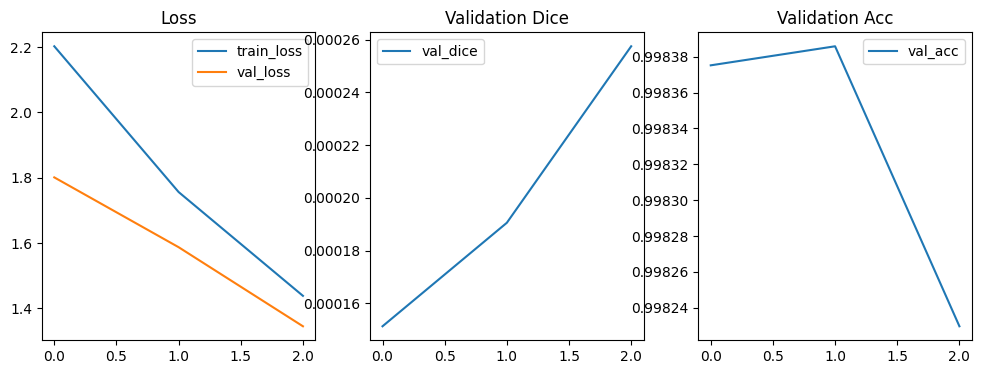

In [25]:
plt.figure(figsize=(12,4))
plt.subplot(1,3,1)
plt.plot(train_loss_hist, label="train_loss")
plt.plot(val_loss_hist, label="val_loss")
plt.legend()
plt.title("Loss")
plt.subplot(1,3,2)
plt.plot(val_dice_hist, label="val_dice")
plt.legend()
plt.title("Validation Dice")
plt.subplot(1,3,3)
plt.plot(val_acc_hist, label="val_acc")
plt.legend()
plt.title("Validation Acc")
plt.show()
